All your life you've never seen, woman <br>
Taken by the wind <br>
Would you stay if she promised you heaven? <br>
Will you ever win? <br>

# Imports and setups

In [1]:
import tensorflow as tf
from tensorflow.python.platform import self_check

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("Memory growth enabled")
    except Exception as e:
        print("Could not set memory growth:", e)

GPUs: []


In [2]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir("D:/Facial Recognition/")
import cv2 
import uuid
tf.config.list_physical_devices('GPU')

[]

# Creating folder structure

In [3]:
POSITIVES = os.path.join("data", "positive")
NEGATIVES = os.path.join("data", "negative")
ANCHORS = os.path.join("data", "anchors")
dirs = [POSITIVES, NEGATIVES, ANCHORS]
for dir in dirs :
    os.makedirs(dir, exist_ok = True)
print(os.path.abspath("data"))

D:\Facial Recognition\data


In [4]:
for directory in os.listdir("lfw"):
    for filename in os.listdir(os.path.join("lfw", directory)):
        EX_PATH = os.path.join("lfw", directory, filename)
        NEW_PATH = os.path.join(NEGATIVES, filename)
        os.replace(EX_PATH, NEW_PATH)

In [5]:
for filename in os.listdir(NEGATIVES):
    print(os.path.join(NEGATIVES, filename))

data\negative\Aaron_Eckhart_0001.jpg
data\negative\Aaron_Guiel_0001.jpg
data\negative\Aaron_Patterson_0001.jpg
data\negative\Aaron_Peirsol_0001.jpg
data\negative\Aaron_Peirsol_0002.jpg
data\negative\Aaron_Peirsol_0003.jpg
data\negative\Aaron_Peirsol_0004.jpg
data\negative\Aaron_Pena_0001.jpg
data\negative\Aaron_Sorkin_0001.jpg
data\negative\Aaron_Sorkin_0002.jpg
data\negative\Aaron_Tippin_0001.jpg
data\negative\Abbas_Kiarostami_0001.jpg
data\negative\Abba_Eban_0001.jpg
data\negative\Abdel_Aziz_Al-Hakim_0001.jpg
data\negative\Abdel_Madi_Shabneh_0001.jpg
data\negative\Abdel_Nasser_Assidi_0001.jpg
data\negative\Abdel_Nasser_Assidi_0002.jpg
data\negative\Abdoulaye_Wade_0001.jpg
data\negative\Abdoulaye_Wade_0002.jpg
data\negative\Abdoulaye_Wade_0003.jpg
data\negative\Abdoulaye_Wade_0004.jpg
data\negative\Abdulaziz_Kamilov_0001.jpg
data\negative\Abdullah_0001.jpg
data\negative\Abdullah_0002.jpg
data\negative\Abdullah_0003.jpg
data\negative\Abdullah_0004.jpg
data\negative\Abdullah_Ahmad_Badaw

# Accessing the WebCam using OpenCV

In [6]:
# verifying if the camera be worken
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*"MJPG"))
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("opened:", cap.isOpened())
ret, frame = cap.read()
print("ret:", ret)

opened: True
ret: True


In [7]:
cap = cv2.VideoCapture(0)
while cap.isOpened() :
    ret, frame = cap.read()
    if not ret :
        break

    frame = frame[120 : 120 + 250, 200 : 200 + 250, :]
    cv2.imshow("Image Collection", frame)
    # collecting the anchors
    if (cv2.waitKey(1) & 0xFF == ord('a')) :
        imgname = os.path.join(ANCHORS, "{}.jpg".format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)
    # collecting the positives
    if (cv2.waitKey(1) & 0xFF == ord('p')) :
        imgname = os.path.join(POSITIVES, "{}.jpg".format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)
    # collecting the negatives
    if (cv2.waitKey(1) & 0xFF == ord('n')) :
        imgname = os.path.join(NEGATIVES, "{}.jpg".format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)

    if (cv2.waitKey(1) & 0xFF == ord('q')) :
        break
cap.release()
cv2.destroyAllWindows()

In [8]:
# # in case of using ip webcam
# import os
# import cv2
# import numpy as np
# from IPython.display import display
# from PIL import Image

# PHONE_STREAM_URL = os.getenv("PHONE_STREAM_URL", "http://192.168.0.108:8080/video")
# print("Using phone stream URL:", PHONE_STREAM_URL)

# cap = cv2.VideoCapture(PHONE_STREAM_URL)

# if not cap.isOpened():
#     raise RuntimeError(
#         "Could not open the phone stream.\n"
#         "Check that IP Webcam is running on your phone and that the URL is correct."
#     )

# cap.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
# cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)

# print("Phone stream opened successfully")
# print("Press q in the notebook cell output to stop")

# for _ in range(30):
#     ret, frame = cap.read()
#     if not ret:
#         print("Failed to read a frame from the phone stream")
#         break

#     frame = cv2.resize(frame, (320, 240))
#     frame = frame[120 : 120 + 250, 200 : 200 + 250, :]
#     frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#     img = Image.fromarray(frame_rgb)
#     display(img)

# cap.release()

In [14]:
anchor = tf.data.Dataset.list_files(ANCHORS + "\\*.jpg").take(300)
positive = tf.data.Dataset.list_files(POSITIVES + "\\*.jpg").take(300)
negative = tf.data.Dataset.list_files(NEGATIVES + "\\*.jpg").take(300)

In [15]:
ANCHORS

'data\\anchors'

In [16]:
def preprocess (file_path) :
    """
    Params : file_path
    Preprocesses the images for the neural network by resizing to (100, 100) and scaling b/w [0, 1] by dividing by 255.0
    """
    byte_img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(byte_img)
    img = tf.image.resize(img, (100, 100))
    # scaling b/w 0 and 1 to make sure numbers dont go all over the place
    img /= 255
    return img


In [13]:
plt.imshow(preprocess("data\anchors\5a8dad50-9c51-11f1-9a31-00155d1ada78.jpg"))
plt.title("BUGGU (scaled down to [100 : 100])")

InvalidArgumentError: {{function_node __wrapped__ReadFile_device_/job:localhost/replica:0/task:0/device:CPU:0}} NewRandomAccessFile failed to Create/Open: datanchorsa8dad50-9c51-11f1-9a31-00155d1ada78.jpg : The filename, directory name, or volume label syntax is incorrect.
; no protocol option [Op:ReadFile]

In [ ]:
preprocess("data//anchors//51a6b4a8-8e5e-11f1-ad31-be86ceb3559f.jpg").numpy()[:, :, 1].min()

NotFoundError: {{function_node __wrapped__ReadFile_device_/job:localhost/replica:0/task:0/device:CPU:0}} NewRandomAccessFile failed to Create/Open: data//anchors//51a6b4a8-8e5e-11f1-ad31-be86ceb3559f.jpg : The system cannot find the file specified.
; No such file or directory [Op:ReadFile]

# Creating Labelled Dataset

In [17]:
positive_dataset = tf.data.Dataset.zip((
    anchor,
    positive,
    tf.data.Dataset.from_tensor_slices(tf.ones([len(anchor)], dtype = tf.float32))
))
negative_dataset = tf.data.Dataset.zip((
    anchor,
    negative,
    tf.data.Dataset.from_tensor_slices(tf.zeros([len(anchor)], dtype = tf.float32))
))
data = positive_dataset.concatenate(negative_dataset)

In [18]:
print(tf.data.experimental.cardinality(positive_dataset).numpy())
print(tf.data.experimental.cardinality(negative_dataset).numpy())
print(tf.data.experimental.cardinality(data).numpy())

300
300
600


In [19]:
data = data.shuffle(600)
len(data)

600

In [20]:
for element in data : print(element)

(<tf.Tensor: shape=(), dtype=string, numpy=b'data\\anchors\\79900900-9c51-11f1-9b64-00155d1ada78.jpg'>, <tf.Tensor: shape=(), dtype=string, numpy=b'data\\positive\\5e7cea64-9c51-11f1-93a8-00155d1ada78.jpg'>, <tf.Tensor: shape=(), dtype=float32, numpy=1.0>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'data\\anchors\\65777706-9c51-11f1-9976-00155d1ada78.jpg'>, <tf.Tensor: shape=(), dtype=string, numpy=b'data\\positive\\6d2005d4-9c51-11f1-be81-00155d1ada78.jpg'>, <tf.Tensor: shape=(), dtype=float32, numpy=1.0>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'data\\anchors\\7b840d27-9c51-11f1-b8f7-00155d1ada78.jpg'>, <tf.Tensor: shape=(), dtype=string, numpy=b'data\\positive\\7812c6ac-9c51-11f1-9d93-00155d1ada78.jpg'>, <tf.Tensor: shape=(), dtype=float32, numpy=1.0>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'data\\anchors\\629fa616-9c51-11f1-bbfd-00155d1ada78.jpg'>, <tf.Tensor: shape=(), dtype=string, numpy=b'data\\positive\\778f2540-9c51-11f1-935e-00155d1ada78.jpg'>, <tf.Tensor: shape=(),

# Build Test and Train partition

In [21]:
samples = data.as_numpy_iterator()

In [22]:
example = samples.next()
example

(b'data\\anchors\\6b1322ea-9c51-11f1-b9a4-00155d1ada78.jpg',
 b'data\\positive\\655a5c9e-9c51-11f1-8d3c-00155d1ada78.jpg',
 np.float32(1.0))

In [23]:
for idx in range (0, len(example)) : print(type(example[idx]))

<class 'bytes'>
<class 'bytes'>
<class 'numpy.float32'>


In [24]:
def preprocess_positive (input_img, validation_img, label) :
    """
    takes an input image and a validation image and process them with process(img)
    """
    return(preprocess(input_img), preprocess(validation_img), label)

Text(0.5, 1.0, 'Boro botla')

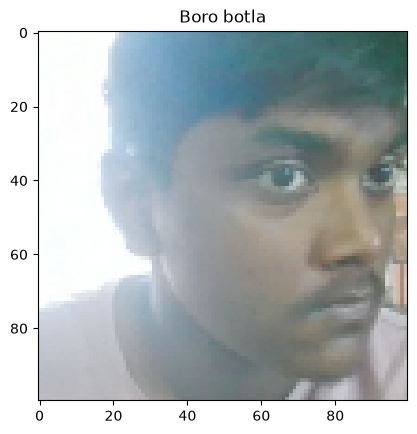

In [25]:
plt.imshow(preprocess_positive(*example)[0])
plt.title("Boro botla")

In [26]:
data = data.map(preprocess_positive)
data = data.cache()
data = data.shuffle(buffer_size = 1024) 

In [27]:
sample = data.as_numpy_iterator()

In [28]:
print(sample.next())

(array([[[0.6343137 , 0.78112745, 0.85490197],
        [0.5348039 , 0.70955884, 0.8002451 ],
        [0.44485295, 0.6360294 , 0.7409314 ],
        ...,
        [0.6816176 , 0.81102943, 0.7443628 ],
        [0.67941177, 0.8088235 , 0.74215686],
        [0.6745098 , 0.8039216 , 0.7372549 ]],

       [[0.577451  , 0.74509805, 0.82254905],
        [0.48406863, 0.66740197, 0.76053923],
        [0.43529412, 0.6306372 , 0.7375    ],
        ...,
        [0.68235296, 0.8117647 , 0.74509805],
        [0.67941177, 0.8088235 , 0.74215686],
        [0.6784314 , 0.80784315, 0.7411765 ]],

       [[0.50416666, 0.6747549 , 0.77181375],
        [0.47720587, 0.65      , 0.75784314],
        [0.44534314, 0.6159314 , 0.7443628 ],
        ...,
        [0.6791667 , 0.80857843, 0.74191177],
        [0.67941177, 0.8088235 , 0.74215686],
        [0.6784314 , 0.80784315, 0.7411765 ]],

       ...,

       [[0.59436274, 0.59044117, 0.6139706 ],
        [0.59656864, 0.5926471 , 0.6159314 ],
        [0.5889706 , 

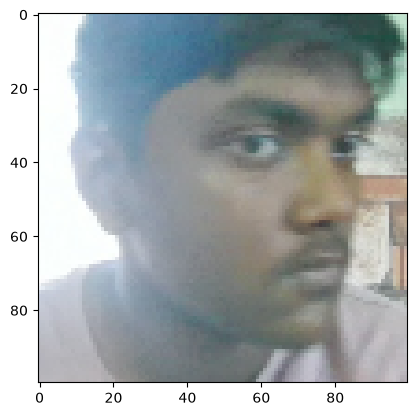

In [29]:
plt.imshow(sample.next()[0])

In [30]:
sample.next()[2]

np.float32(1.0)

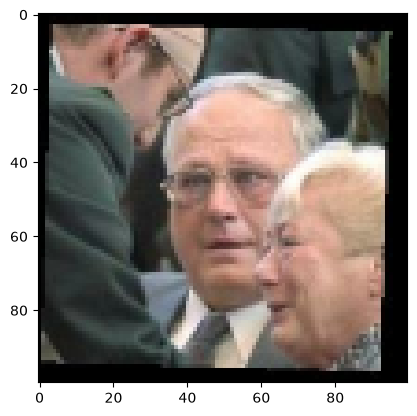

In [31]:
plt.imshow(sample.next()[1])

# Train-Test Split

In [32]:
train_data = data.take(round(len(data) * 0.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [33]:
test_data = data.skip(round(len(data) * 0.7))
test_data = data.take(round(len(data) * 0.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

# Creating the model

In [34]:
from keras import Sequential

embedding = Sequential([
    Input((100, 100, 3), name = "input_layer"),
    Conv2D(64, (10, 10), activation = "relu", name = "conv_1"),
    MaxPooling2D(64, (2, 2), name = "max_pool_1", padding = "same"),
    Conv2D(128, (7, 7), activation = "relu", name = "conv_2"),
    MaxPooling2D(64, (2, 2), name = "max_pool_2", padding = "same"),
    Conv2D(128, (4, 4), activation = "relu", name = "conv_3"),
    MaxPooling2D(64, (2, 2), name = "max_pool_3", padding = "same"),
    Conv2D(256, (4, 4), activation = "relu", name = "conv_4"),
    Flatten(),
    Dense(4096, activation="sigmoid")
], name = "embedding_model")

embedding.compile()
embedding.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 91, 91, 64)     │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 40, 40, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 17, 17, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_3 (MaxPooling2D)       │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 6, 6, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,960,448 (148.62 MB)

 Trainable params: 38,960,448 (148.62 MB)

 Non-trainable params: 0 (0.00 B)

# Building the distance layer

In [35]:
# Siamese Distance Class

class L1_distance (Layer) :
    def __init__ (self, **kwargs) :
        super().__init__()

    def call (self, input_embedding, validation_embedding) :
        return tf.math.abs(input_embedding - validation_embedding)

In [36]:
layer1 = L1_distance()

In [37]:
int(layer1.call(6, 7))

1

# Make Siamese Model

In [38]:
def siamese () :
    input_image = Input(shape = (100, 100, 3), name = "input_image")
    validation_image = Input(shape = (100, 100, 3), name = "validation_image")
    siamese_layer = L1_distance()
    siamese_layer.__name__ = "distance"
    distances = siamese_layer(embedding(input_image), embedding(validation_image))
    classifier = Dense(1, activation = "sigmoid") (distances)
    return Model(inputs = [input_image, validation_image], outputs = classifier, name = "siamese_net")

In [39]:
input_image = Input(shape = (100, 100, 3), name = "input_image")
validation_image = Input(shape = (100, 100, 3), name = "validation_image")

In [40]:
siamese_neural_network = siamese()
siamese_neural_network.summary()

Model: "siamese_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_image    │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 4096)      │ 38,960,448 │ input_image[0][0… │
│ (Sequential)        │                   │            │ validation_image… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_distance_1       │ (None, 4096)      │          0 │ embedding_model[… │
│ (L1_distance)       │                   │            │ embedding_model[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      4,097 │ l1_distance_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

# Training the model

## Setting up the Loss and the Optimizer

In [41]:
loss_function = tf.losses.BinaryCrossentropy()
optimizer = tf.keras.optimizers.AdamW(1e-4)


## Establishing Checkpoints

In [42]:
checkpoint_directory = "./training_checkpoints"
checkpoint_prefix = os.path.join(checkpoint_directory, "checkpoint")
checkpoint = tf.train.Checkpoint(optimizer = optimizer, siamese = siamese_neural_network)

## Build train step func

In [43]:
@tf.function
def train_step (batch) :
    with tf.GradientTape as tape :
        X = batch[:2]
        y = batch[:2]
        y_pred = siamese(X, training = True)
        loss = loss_function(y, y_pred)
    print(loss)

    gradient = tape.gradient(loss, siamese_neural_network.trainable_variables)
    optimizer.apply_gradients(zip(gradient, siamese_neural_network.trainable_variables))

    return loss



## Train.

In [44]:
@tf.function
def train_step(batch):
    with tf.GradientTape() as tape:
        input_image, validation_image, y = batch
        y_pred = siamese_neural_network([input_image, validation_image], training=True)
        loss = loss_function (y, y_pred)

    gradients = tape.gradient(loss, siamese_neural_network.trainable_variables)
    optimizer.apply_gradients(zip(gradients, siamese_neural_network.trainable_variables))
    return loss

In [45]:
def model_train(data : any, EPOCHS : int) :
    for epoch in (1, EPOCHS + 1) :
        print("\n Epoch : {} / {}", epoch, EPOCHS)
        progress_bar = tf.keras.utils.Progbar(len(data))

        for idx, batch in enumerate (data) :
            train_step(batch)
            progress_bar.update(idx + 1)

        if (epoch % 10 == 0) :
            checkpoint.save(file_prefix = checkpoint_prefix)

In [47]:
@tf.function
def train_step(batch):
    with tf.GradientTape() as tape:
        input_image, validation_image, y = batch
        y_pred = siamese_neural_network([input_image, validation_image], training=True)
        loss = loss_function(y, y_pred)

    gradients = tape.gradient(loss, siamese_neural_network.trainable_variables)
    optimizer.apply_gradients(zip(gradients, siamese_neural_network.trainable_variables))
    return loss

losses = []
def model_train(data, EPOCHS):
    
    for epoch in range(1, EPOCHS + 1):
        print(f"\n Epoch : {epoch} / {EPOCHS}")
        progress_bar = tf.keras.utils.Progbar(int(tf.data.experimental.cardinality(data).numpy()))
        for idx, batch in enumerate(data):
            loss = train_step(batch)
            losses.append(loss)
            progress_bar.update(idx + 1, values=[("loss", loss)])
        if epoch % 10 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

model_train(data=train_data, EPOCHS = 50)


 Epoch : 1 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 950ms/step - loss: 0.3294

 Epoch : 2 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 909ms/step - loss: 0.1310

 Epoch : 3 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 920ms/step - loss: 0.0204

 Epoch : 4 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 920ms/step - loss: 0.0070

 Epoch : 5 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 900ms/step - loss: 0.0173

 Epoch : 6 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 912ms/step - loss: 9.6778e-04

 Epoch : 7 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 930ms/step - loss: 1.2849e-09

 Epoch : 8 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 951ms/step - loss: 0.1016

 Epoch : 9 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 955ms/step - loss: 0.0017

 Epoch : 10 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - loss: 0.0085

 Epoch : 11 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - loss: 7.9368e-07

 Epoch : 12 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 4.2725e-08

 Epoch : 13 / 50
27/27 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - loss: 0.0042

 Epoch : 14 / 50
27/27 ━━━━━━

In [48]:
len(losses)

1350

# Evaluate the model

In [49]:
from tensorflow.keras.metrics import Precision, Recall

In [50]:
test_input, test_val, y_true = test_data.as_numpy_iterator().next()

In [51]:
y_pred = siamese_neural_network.predict([test_input, test_val])
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step


array([[2.57448041e-16],
       [3.78058739e-12],
       [9.99651909e-01],
       [9.99985278e-01],
       [1.23532884e-13],
       [9.99920964e-01],
       [9.92934118e-15],
       [2.17606629e-16],
       [1.08080904e-14],
       [1.28237891e-14],
       [9.97397006e-01],
       [9.99614775e-01],
       [9.99971271e-01],
       [9.93271410e-01],
       [1.17799982e-16],
       [1.00000000e+00]], dtype=float32)

In [52]:
[1 if prediction > 0.5 else 0 for prediction in y_pred]

[0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1]

In [53]:
y_true

array([0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 1.],
      dtype=float32)

In [54]:
m = Recall()
m.update_state(y_true, y_pred)
m.result().numpy()

np.float32(1.0)

In [55]:
n = Precision()
n.update_state(y_true, y_pred)
n.result().numpy()

np.float32(1.0)

In [56]:
accuracy = tf.metrics.Accuracy()
accuracy.update_state(y_true, y_pred)
accuracy.result().numpy()

np.float32(0.0625)

Model Diagnostic Overview
Examples evaluated: 180
Average test loss:  0.0022
Accuracy:           1.0000
Precision:          1.0000
Recall:             1.0000
F1 score:           1.0000

Confusion matrix [rows = actual, columns = predicted]
                 Predicted 0  Predicted 1
Actual 0                   97             0
Actual 1                    0            83


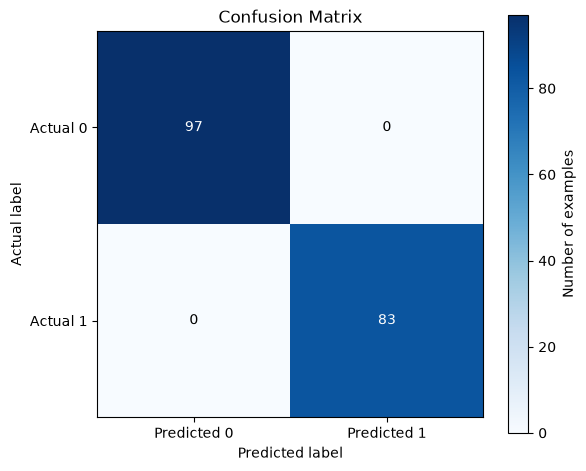

In [77]:
# Full test-set diagnostic overview
all_y_true = []
all_y_pred = []
test_losses = []

for input_batch, validation_batch, labels_batch in test_data:
    predictions_batch = siamese_neural_network.predict(
        [input_batch, validation_batch], verbose=0
    )
    test_losses.append(
        float(loss_function(labels_batch, predictions_batch).numpy())
    )
    all_y_true.append(np.asarray(labels_batch).reshape(-1))
    all_y_pred.append(np.asarray(predictions_batch).reshape(-1))

y_true_all = np.concatenate(all_y_true).astype(int)
y_pred_scores = np.concatenate(all_y_pred)
y_pred_all = (y_pred_scores >= 0.5).astype(int)

true_positives = np.sum((y_true_all == 1) & (y_pred_all == 1))
false_positives = np.sum((y_true_all == 0) & (y_pred_all == 1))
false_negatives = np.sum((y_true_all == 1) & (y_pred_all == 0))

precision_value = true_positives / (true_positives + false_positives) if true_positives + false_positives else 0.0
recall_value = true_positives / (true_positives + false_negatives) if true_positives + false_negatives else 0.0
accuracy_value = np.mean(y_true_all == y_pred_all)
f1_value = (2 * precision_value * recall_value / (precision_value + recall_value)
             if precision_value + recall_value else 0.0)
confusion_matrix = tf.math.confusion_matrix(
    y_true_all, y_pred_all, num_classes=2
).numpy()

print("Model Diagnostic Overview")
print("=" * 28)
print(f"Examples evaluated: {len(y_true_all)}")
print(f"Average test loss:  {np.mean(test_losses):.4f}")
print(f"Accuracy:           {accuracy_value:.4f}")
print(f"Precision:          {precision_value:.4f}")
print(f"Recall:             {recall_value:.4f}")
print(f"F1 score:           {f1_value:.4f}")
print("\nConfusion matrix [rows = actual, columns = predicted]")
print("                 Predicted 0  Predicted 1")
print(f"Actual 0         {confusion_matrix[0, 0]:12d}  {confusion_matrix[0, 1]:12d}")
print(f"Actual 1         {confusion_matrix[1, 0]:12d}  {confusion_matrix[1, 1]:12d}")

plt.figure(figsize=(6, 5))
plt.imshow(confusion_matrix, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar(label="Number of examples")
plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
plt.xlabel("Predicted label")
plt.ylabel("Actual label")

for row in range(2):
    for column in range(2):
        plt.text(
            column,
            row,
            confusion_matrix[row, column],
            ha="center",
            va="center",
            color="white" if confusion_matrix[row, column] > confusion_matrix.max() / 2 else "black",
        )

plt.tight_layout()
plt.show()

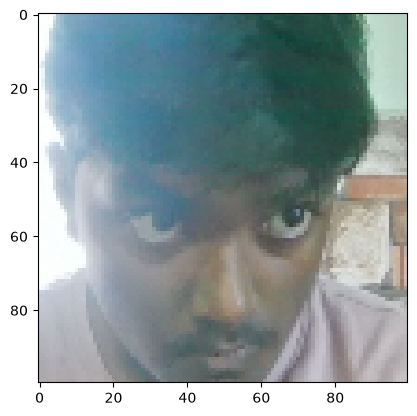

In [57]:
plt.imshow(test_input[0])


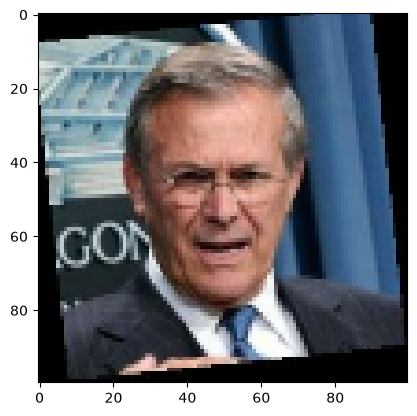

In [58]:
plt.imshow(test_val[0])

In [79]:
siamese_neural_network.save("siamese_neural_network.keras")

In [60]:
L1_distance

__main__.L1_distance

In [61]:
model = keras.models.load_model(
                                "siamese_neural_network.keras", 
                                custom_objects = {
                                    'L1_distance' : L1_distance, 
                                    'BinaryCrossentropy' : tf.losses.BinaryCrossentropy
                                    }
                                )

d:\Facial Recognition\.facial_rec\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [62]:
model.predict([test_input, test_val])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step


array([[2.57448041e-16],
       [3.78058739e-12],
       [9.99651909e-01],
       [9.99985278e-01],
       [1.23532884e-13],
       [9.99920964e-01],
       [9.92934118e-15],
       [2.17606629e-16],
       [1.08080904e-14],
       [1.28237891e-14],
       [9.97397006e-01],
       [9.99614775e-01],
       [9.99971271e-01],
       [9.93271410e-01],
       [1.17799982e-16],
       [1.00000000e+00]], dtype=float32)

In [63]:
model.summary()

Model: "siamese_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_image    │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 4096)      │ 38,960,448 │ input_image[0][0… │
│ (Sequential)        │                   │            │ validation_image… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_distance_2       │ (None, 4096)      │          0 │ embedding_model[… │
│ (L1_distance)       │                   │            │ embedding_model[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      4,097 │ l1_distance_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

# Real time verification 

In [64]:
os.listdir(os.path.join("application_data", "verification_images"))

['446aa963-8e9a-11f1-85d1-be86ceb3559f.jpg',
 '45f8889f-8e9a-11f1-b8a6-be86ceb3559f.jpg',
 '46122daf-8e9a-11f1-8abc-be86ceb3559f.jpg',
 '46ca7048-8e9a-11f1-87cc-be86ceb3559f.jpg',
 '481cb018-8e9a-11f1-ab4a-be86ceb3559f.jpg',
 '48368956-8e5e-11f1-9b10-be86ceb3559f.jpg',
 '484c31b0-8e9a-11f1-a56b-be86ceb3559f.jpg',
 '4892af08-8e9a-11f1-8a5a-be86ceb3559f.jpg',
 '48c08c6e-8e5e-11f1-a5eb-be86ceb3559f.jpg',
 '4a3e6fa9-8e9a-11f1-b83d-be86ceb3559f.jpg',
 '4a715f15-8e9a-11f1-9c76-be86ceb3559f.jpg',
 '4b4829ab-8e9a-11f1-8ae3-be86ceb3559f.jpg',
 '4ba14728-8e5e-11f1-97ae-be86ceb3559f.jpg',
 '4bb83300-8e9a-11f1-95f1-be86ceb3559f.jpg',
 '510c1d73-8e9a-11f1-b7fb-be86ceb3559f.jpg',
 '5708eb5d-92a3-11f1-9686-ae0719567331.jpg',
 '576f0385-92a3-11f1-a0a3-ae0719567331.jpg',
 '5a686aaf-9218-11f1-ace1-00155df46725.jpg',
 '5a73bf2f-9218-11f1-af19-00155df46725.jpg',
 '5a861ac4-9218-11f1-93c8-00155df46725.jpg',
 '5a8b6e3c-9218-11f1-a390-00155df46725.jpg',
 '5a9a7c44-9218-11f1-878a-00155df46725.jpg',
 '5aa09069

In [65]:
def verify (model, detection_threshold, verification_threshold) :
    """
    Takes live webcame input and verifies against verification folder
    """
    results = []
    for image in os.listdir(os.path.join("application_data", "verification_images")) :
        input_img = preprocess(os.path.join("application_data", "input_images", "input_image.jpg"))
        validation_img = preprocess(os.path.join("application_data", "verification_images", image))
        result = model.predict([np.expand_dims(input_img, 0), np.expand_dims(validation_img, 0)])
        # Extract scalar value from prediction (model returns shape (1, 1))
        results.append(result[0][0])

    # Convert to numpy array of scalars for proper comparison
    results_array = np.array(results)
    detection = np.sum(results_array > detection_threshold)

    verification = detection / len(results)
    verified = verification > verification_threshold
    print(verified)

    return results, verified

# OpenCV realtime verification

In [ ]:
cap = cv2.VideoCapture(0)

while cap.isOpened() :
    ret, frame = cap.read()
    frame = frame[120 : 120 + 250, 200 : 200 + 250, :]
    cv2.imshow('Verification', frame) 
    if cv2.waitKey(10) & 0xFF == ord('v') :
        cv2.imwrite(os.path.join('application_data', 'input_images', 'input_image.jpg'), frame)
        results, verified = verify(model, 0.7, 0.7)
        print(verified)
    if cv2.waitKey(10) & 0xFF == ord('q') : 
        break
cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━

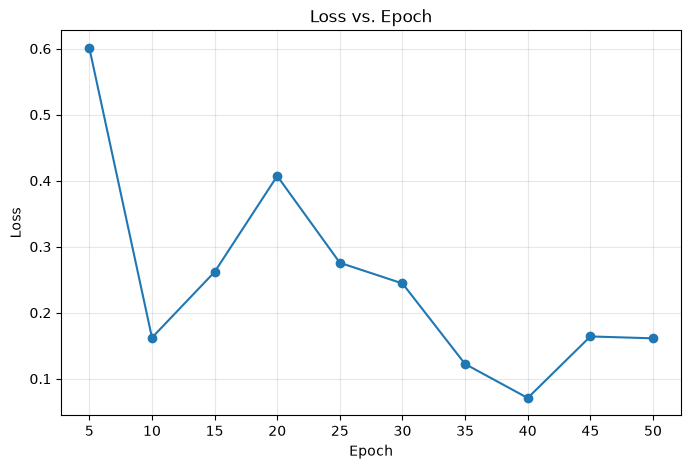

In [75]:
import matplotlib.pyplot as plt

if len(losses) < 50:
    raise ValueError(f"Expected at least 50 loss values, but got {len(losses)}")

epochs = list(range(5, 51, 5))
sampled_losses = [losses[epoch - 1] for epoch in epochs]

plt.figure(figsize=(8, 5))
plt.plot(epochs, sampled_losses, marker="o")
plt.xticks(epochs)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs. Epoch")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
np.squeeze(results) > 0.5

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])